# 07 - Pitfalls and simulations

**Goal:** show, with the real data and with simulations, two of the most common ways an
A/B test analysis goes wrong.

Knowing what *not* to do separates someone who can run a test from someone who can be
trusted to analyze one. A simulation proves the point instead of merely asserting it,
because the true effect is known by construction.

In [1]:
import pandas as pd                                        # tables
import numpy as np                                         # maths and random numbers
import matplotlib.pyplot as plt                            # charts
from scipy import stats                                    # normal distribution
from pathlib import Path                                   # file paths

pd.set_option("display.max_columns", None)                 # never hide columns
pd.set_option("display.width", 200)                        # wide printing

In [2]:
ROOT = Path.cwd()                                          # folder the notebook runs in
if ROOT.name == "notebooks":                               # if inside notebooks/...
    ROOT = ROOT.parent                                     # ...go up to the project root
FIG_DIR = ROOT / "reports" / "figures"                     # charts folder
df = pd.read_csv(ROOT / "data" / "processed" / "cookie_cats_clean.csv")   # cleaned data

## Pitfall 1: filtering on a post-treatment variable

It is tempting to say "only players who reached 40 rounds actually experienced both gates,
so compare those." But rounds played happen *after* assignment and the gate itself changes
them, so the filtered groups no longer contain the same kinds of players.

In [3]:
overall = df.groupby("version")["retention_7"].mean() * 100                                 # correct comparison: all randomized players
filtered = df[df["sum_gamerounds"] >= 40].groupby("version")["retention_7"].mean() * 100    # tempting but biased: only players with 40+ rounds
filtered_counts = df[df["sum_gamerounds"] >= 40]["version"].value_counts()                  # how many players survive the filter per group
comparison = pd.DataFrame({"all_players_d7_pct": overall, "only_40plus_rounds_d7_pct": filtered, "players_left_after_filter": filtered_counts})   # side by side
print(comparison.round(3))                                                                  # the gap changes size once we filter
print("Diff (all players, pp):", round(overall["gate_40"] - overall["gate_30"], 3))         # the valid estimate
print("Diff (40+ rounds only, pp):", round(filtered["gate_40"] - filtered["gate_30"], 3))   # NOT a valid causal estimate

         all_players_d7_pct  only_40plus_rounds_d7_pct  players_left_after_filter
version                                                                          
gate_30               19.02                     50.287                      13566
gate_40               18.20                     48.507                      13827
Diff (all players, pp): -0.82
Diff (40+ rounds only, pp): -1.781


**Checkpoint**

| | All players D7 | Only 40+ rounds D7 | Players left |
|---|---|---|---|
| gate_30 | 19.020% | 50.287% | 13,566 |
| gate_40 | 18.200% | 48.507% | 13,827 |

The valid difference is -0.82 pp. After filtering it reads -1.781 pp, more than twice as large.

In [4]:
rng = np.random.default_rng(seed=5)                        # fixed seed
n_players = 200000                                         # simulated players
treatment = rng.integers(0, 2, size=n_players)             # random assignment: 0 = control, 1 = treatment
enjoyment = rng.normal(0, 1, size=n_players)               # hidden trait: how much each player enjoys the game
retention_prob = 1 / (1 + np.exp(-(-1.5 + 1.2 * enjoyment)))   # retention depends ONLY on enjoyment, never on treatment
retained = rng.random(n_players) < retention_prob          # draw True/False retention
base_rounds = np.exp(3.0 + 0.9 * enjoyment + rng.normal(0, 0.6, size=n_players))   # rounds grow with enjoyment
rounds = np.where(treatment == 1, base_rounds * 1.25, base_rounds)                 # treatment makes everyone play 25% more rounds (but does not change retention)
sim = pd.DataFrame({"treatment": treatment, "retained": retained, "rounds": rounds})   # put it in a table
true_diff = 100 * (sim.loc[sim["treatment"] == 1, "retained"].mean() - sim.loc[sim["treatment"] == 0, "retained"].mean())   # should be about 0
kept = sim[sim["rounds"] >= 40]                            # the same tempting filter as before
filtered_diff = 100 * (kept.loc[kept["treatment"] == 1, "retained"].mean() - kept.loc[kept["treatment"] == 0, "retained"].mean())   # biased
print("Simulated true effect on retention (pp):", round(true_diff, 3))        # about 0: correct
print("Effect after filtering to 40+ rounds (pp):", round(filtered_diff, 3))  # clearly negative: a fake effect created by the filter

Simulated true effect on retention (pp): -0.02
Effect after filtering to 40+ rounds (pp): -3.343


**Checkpoint:** true effect about -0.02 pp (essentially zero), and about -3.3 pp after filtering.

In this simulation the treatment has **zero** effect on retention by construction. It only makes
everyone play 25% more rounds. Because of those extra rounds, players with low enjoyment cross the
40-round line more often in the treatment group, so the filtered treatment group holds more
low-enjoyment players, who retain less. A fake negative effect appears out of nothing. That is
exactly why all randomized players are analyzed.

## Pitfall 2: peeking at results every day

Each extra look is another chance for random noise to cross the significance line. An A/A test -
where both groups are identical - makes this easy to measure, because every "significant" result
is by definition a false positive.

In [5]:
rng_peek = np.random.default_rng(seed=99)                  # fixed seed
n_experiments = 2000                                       # simulated A/A experiments (no real difference exists)
n_days = 14                                                # each experiment runs 14 days
players_per_day = 3000                                     # new players per group per day
true_rate = 0.19                                           # identical D7 rate in both groups
z_crit = stats.norm.ppf(0.975)                             # 1.96 for alpha = 0.05 two-sided
days = np.arange(1, n_days + 1)                            # day numbers 1..14
cum_n = players_per_day * days                             # cumulative players per group after each day
max_abs_z = np.empty(n_experiments)                        # biggest |z| seen during each experiment
final_abs_z = np.empty(n_experiments)                      # |z| on the final day only
for i in range(n_experiments):                             # one loop, one experiment per iteration
    daily_a = rng_peek.binomial(players_per_day, true_rate, size=n_days)   # retained players per day, group A
    daily_b = rng_peek.binomial(players_per_day, true_rate, size=n_days)   # retained players per day, group B
    cum_a = np.cumsum(daily_a)                             # running total retained, group A
    cum_b = np.cumsum(daily_b)                             # running total retained, group B
    rate_a = cum_a / cum_n                                 # running retention rate, group A
    rate_b = cum_b / cum_n                                 # running retention rate, group B
    pooled = (cum_a + cum_b) / (2 * cum_n)                 # pooled rate on each day
    se = np.sqrt(pooled * (1 - pooled) * (2 / cum_n))      # standard error on each day
    z_by_day = (rate_b - rate_a) / se                      # z-statistic on each day (14 numbers at once)
    max_abs_z[i] = np.max(np.abs(z_by_day))                # largest |z| if we checked every day
    final_abs_z[i] = np.abs(z_by_day[-1])                  # |z| if we only checked at the end
fpr_peeking = np.mean(max_abs_z > z_crit)                  # share of A/A tests "significant" at ANY daily look
fpr_final = np.mean(final_abs_z > z_crit)                  # share "significant" when looking only once
print("False positive rate, checked once at the end:", round(fpr_final, 3))   # about 0.05
print("False positive rate, checked every day:", round(fpr_peeking, 3))       # much higher than 0.05

False positive rate, checked once at the end: 0.05
False positive rate, checked every day: 0.216


**Checkpoint:** about 0.050 when checked once, about 0.216 when checked every day.

Checking daily for 14 days and stopping at the first p < 0.05 lifts the false-positive rate from
about 5% to about 22%. Roughly one in five "wins" found that way would be fake.

In [6]:
peeking_boundary = np.quantile(max_abs_z, 0.95)            # |z| threshold that only 5% of A/A tests ever cross
print("Calibrated boundary for 14 daily looks:", round(peeking_boundary, 3))   # noticeably bigger than 1.96
check_max_abs_z = np.empty(n_experiments)                  # fresh simulations to check the boundary honestly
for i in range(n_experiments):                             # one loop, one new experiment per iteration
    daily_a = rng_peek.binomial(players_per_day, true_rate, size=n_days)   # new group A data
    daily_b = rng_peek.binomial(players_per_day, true_rate, size=n_days)   # new group B data
    cum_a = np.cumsum(daily_a)                             # running totals A
    cum_b = np.cumsum(daily_b)                             # running totals B
    pooled = (cum_a + cum_b) / (2 * cum_n)                 # pooled rate per day
    se = np.sqrt(pooled * (1 - pooled) * (2 / cum_n))      # standard error per day
    z_by_day = (cum_b / cum_n - cum_a / cum_n) / se        # z per day
    check_max_abs_z[i] = np.max(np.abs(z_by_day))          # largest |z| across the looks
print("False positive rate with calibrated boundary (new sims):", round(np.mean(check_max_abs_z > peeking_boundary), 3))   # back near 0.05

Calibrated boundary for 14 daily looks: 2.632
False positive rate with calibrated boundary (new sims): 0.058


**Checkpoint:** a boundary of about 2.632 and a false-positive rate of about 0.058 on fresh simulations.
(The check set is a fresh 2,000 experiments, so its rate wobbles around 0.05 by roughly one
simulation standard error, about 0.005.)

A team that must look daily needs a stricter threshold than 1.96. The boundary is calibrated on one
set of simulations and then checked on a **fresh** set, because testing a rule on the same data used
to build it would flatter it. Real experimentation platforms use formal sequential testing methods
built on this idea.

**Simplification worth mentioning if asked:** in real life D7 retention for players who installed
today is not known until seven days later. The simulation ignores that lag to keep the point clear.

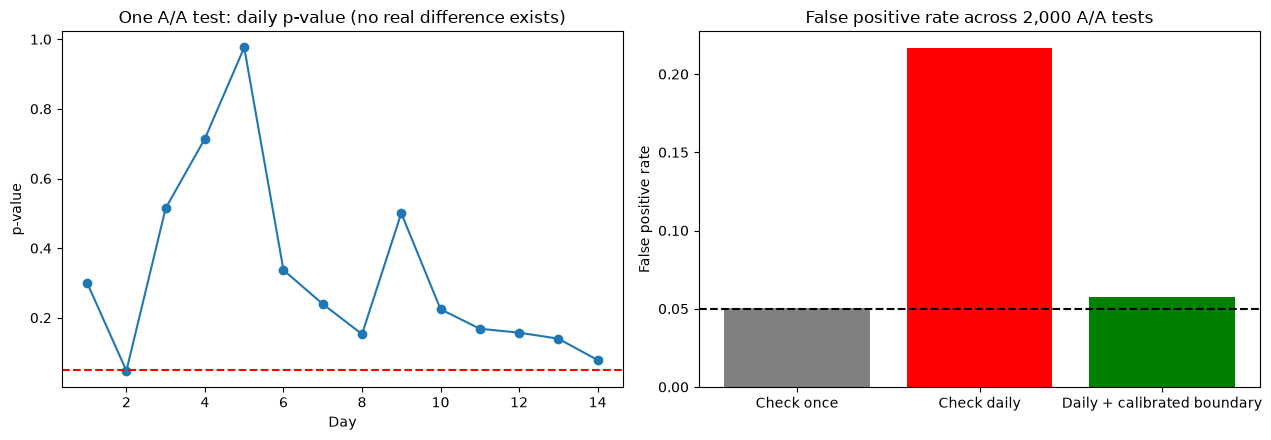

In [7]:
example_a = rng_peek.binomial(players_per_day, true_rate, size=n_days)     # one more A/A experiment
example_b = rng_peek.binomial(players_per_day, true_rate, size=n_days)
ex_cum_a = np.cumsum(example_a)                            # running totals A
ex_cum_b = np.cumsum(example_b)                            # running totals B
ex_pooled = (ex_cum_a + ex_cum_b) / (2 * cum_n)            # pooled rate per day
ex_se = np.sqrt(ex_pooled * (1 - ex_pooled) * (2 / cum_n)) # standard error per day
ex_z = (ex_cum_b / cum_n - ex_cum_a / cum_n) / ex_se       # z per day
ex_p = 2 * (1 - stats.norm.cdf(np.abs(ex_z)))              # p-value per day
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))          # two charts side by side
axes[0].plot(days, ex_p, marker="o")                       # p-value path over 14 days
axes[0].axhline(0.05, color="red", linestyle="--")         # the 0.05 line
axes[0].set_title("One A/A test: daily p-value (no real difference exists)")   # title
axes[0].set_xlabel("Day")                                  # x label
axes[0].set_ylabel("p-value")                              # y label
axes[1].bar(["Check once", "Check daily", "Daily + calibrated boundary"], [fpr_final, fpr_peeking, np.mean(check_max_abs_z > peeking_boundary)], color=["grey", "red", "green"])   # FPR comparison
axes[1].axhline(0.05, color="black", linestyle="--")       # target 5%
axes[1].set_title("False positive rate across 2,000 A/A tests")   # title
axes[1].set_ylabel("False positive rate")                  # y label
fig.tight_layout()                                         # tidy
fig.savefig(FIG_DIR / "11_peeking_simulation.png", dpi=150)   # save
plt.show()                                                 # display

## What these two simulations change about the main analysis

- Every retention number in notebook 04 uses **all** randomized players, never a subgroup defined
  by behavior that happened after assignment.
- The analysis was run once, at the end, against a plan written in advance - no daily peeking and
  no stopping at the first significant look.